In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
# Load your cleaned dataset
df = pd.read_csv('_cancer_dataset_uae.csv')

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   10000 non-null  int64 
 1   Gender                10000 non-null  object
 2   Nationality           10000 non-null  object
 3   Emirate               10000 non-null  object
 4   Cancer_Type           10000 non-null  object
 5   Cancer_Stage          10000 non-null  object
 6   Treatment_Type        10000 non-null  object
 7   Treatment_Start_Date  10000 non-null  object
 8   Hospital              10000 non-null  object
 9   Primary_Physician     10000 non-null  object
 10  Outcome               10000 non-null  object
 11  Death_Date            992 non-null    object
 12  Cause_of_Death        992 non-null    object
 13  Smoking_Status        10000 non-null  object
 14  Comorbidities         5953 non-null   object
 15  Ethnicity             10000 non-null 

In [15]:
features = ['Age', 'Gender', 'Nationality', 'Ethnicity',
            'Smoking_Status', 'Comorbidities', 'Cancer_Type',
            'Weight', 'Height']

target = 'Cancer_Stage'

In [17]:
# Drop rows where target is missing
df_model = df.dropna(subset=[target])

# Drop rows with missing feature values
df_model = df_model[features + [target]].dropna()

# Encode categorical variables
df_encoded = df_model.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Scale numerical features
scaler = StandardScaler()
df_encoded[['Age', 'Weight', 'Height']] = scaler.fit_transform(df_encoded[['Age', 'Weight', 'Height']])

In [19]:
X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

           0       0.23      0.18      0.20       289
           1       0.30      0.39      0.34       359
           2       0.29      0.36      0.32       362
           3       0.28      0.09      0.13       181

    accuracy                           0.28      1191
   macro avg       0.27      0.25      0.25      1191
weighted avg       0.28      0.28      0.27      1191



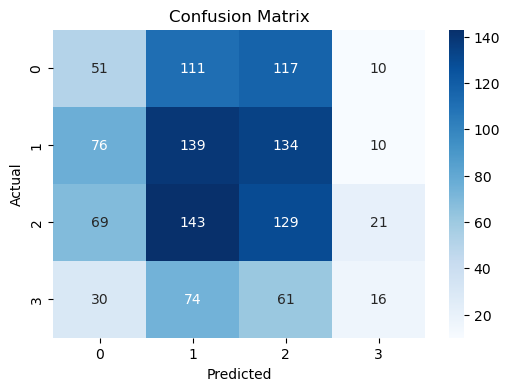

In [23]:
# Predictions
y_pred = model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

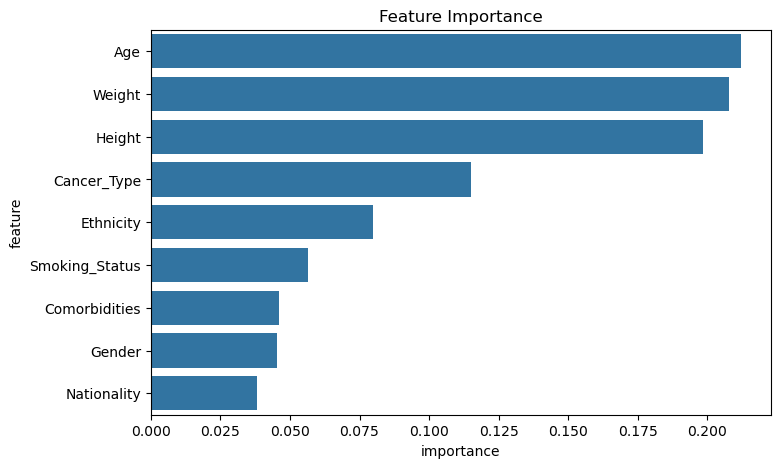

In [25]:
importances = model.feature_importances_
feature_names = X.columns

# Create a feature importance DataFrame
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance')
plt.show()

In [29]:
import joblib
joblib.dump(model, 'cancer_stage_predictor.pkl')

['cancer_stage_predictor.pkl']